# Lexical Processing & NLP Layers: Hands-On (SNLP Lectures 1–2)

Companion notebook for `01-Information-Layers-of-SNLP.md` and `02-Lexical-Processing-Part-1.md`. Uses only **NLTK** (no GPU needed).

> The professor also shared a Colab notebook for Lecture 2: [course Colab link](https://colab.research.google.com/drive/1I5S7q_jiuAACft0xSXBos0qJwvWnYGKn?usp=sharing). This notebook is an independent, extended version.

| Part | Topic |
|---|---|
| A | Types vs tokens (incl. the slide examples), type–token ratio, Heaps' law |
| B | Stemming (Porter, with its cascade rules) vs lemmatization (WordNet) |
| C | Morphological parsing: a toy affix stripper |
| D | Sentence segmentation: why "." is hard |
| E | Tokenization issues: regex tokenizer vs `.split()` |
| F | Normalization & case folding |
| G | Subword tokens (BPE from scratch): handling unseen words like *unavailable* |
| H | Syntax layer: parse "Alice eats strawberries with chocolate" |
| I | Pragmatics/semantics teaser: word-sense ambiguity of "bank" |

In [1]:
import re
from collections import Counter
import nltk
for p in ["punkt", "punkt_tab", "wordnet", "omw-1.4", "averaged_perceptron_tagger_eng", "gutenberg"]:
    nltk.download(p, quiet=True)
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import matplotlib.pyplot as plt

## Part A — Types vs tokens

In [2]:
def types_tokens(text, lower=False):
    toks = text.split()                      # space-based tokenization (as on the slides)
    if lower:
        toks = [t.lower() for t in toks]
    return len(toks), len(set(toks)), sorted(set(toks))

for s in ["The cat chased the cat", "Data is the new oil. Data drives decisions."]:
    for lower in [False, True]:
        n_tok, n_typ, typ = types_tokens(s, lower)
        print(f"{s!r:50s} lower={lower!s:5s} tokens={n_tok} types={n_typ} {typ}")

'The cat chased the cat'                           lower=False tokens=5 types=4 ['The', 'cat', 'chased', 'the']
'The cat chased the cat'                           lower=True  tokens=5 types=3 ['cat', 'chased', 'the']
'Data is the new oil. Data drives decisions.'      lower=False tokens=8 types=7 ['Data', 'decisions.', 'drives', 'is', 'new', 'oil.', 'the']
'Data is the new oil. Data drives decisions.'      lower=True  tokens=8 types=7 ['data', 'decisions.', 'drives', 'is', 'new', 'oil.', 'the']


⚠️ Notice: "The cat chased the cat" has **3 types only if you lowercase** ("The" ≠ "the" otherwise → 4). And with plain `.split()`, "oil." keeps its full stop, so "oil" and "oil." would count as different types. **Every count depends on tokenization and normalization choices.**

In [3]:
# Vocabulary richness: type–token ratio (TTR) across authors (professor's '100 words vs 1000 words' example)
from nltk.corpus import gutenberg
N = 20000
for fid in ["austen-emma.txt", "melville-moby_dick.txt", "carroll-alice.txt", "bible-kjv.txt"]:
    words = [w.lower() for w in gutenberg.words(fid) if w.isalpha()][:N]
    print(f"{fid:24s} first {N} tokens → {len(set(words)):5d} types, TTR = {len(set(words))/N:.3f}")

austen-emma.txt          first 20000 tokens →  2544 types, TTR = 0.127


melville-moby_dick.txt   first 20000 tokens →  4357 types, TTR = 0.218
carroll-alice.txt        first 20000 tokens →  2162 types, TTR = 0.108


bible-kjv.txt            first 20000 tokens →  1663 types, TTR = 0.083


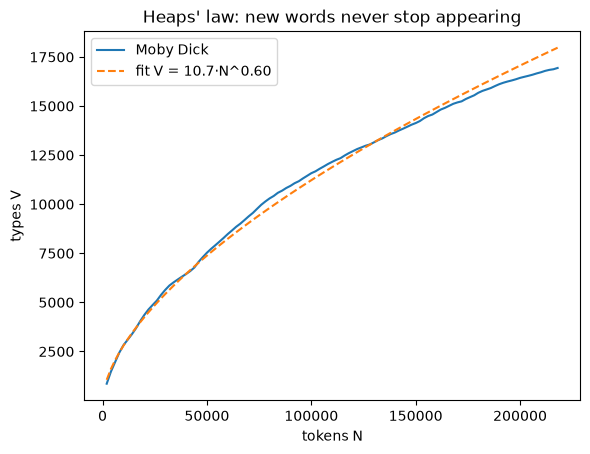

In [4]:
# Heaps' law: vocabulary keeps growing with corpus size, V ≈ k·N^β (β ≈ 0.4–0.6)
words = [w.lower() for w in gutenberg.words("melville-moby_dick.txt") if w.isalpha()]
seen, xs, ys = set(), [], []
for i, w in enumerate(words, 1):
    seen.add(w)
    if i % 2000 == 0:
        xs.append(i); ys.append(len(seen))
import numpy as np
beta, logk = np.polyfit(np.log(xs), np.log(ys), 1)
plt.plot(xs, ys, label="Moby Dick")
plt.plot(xs, np.exp(logk) * np.array(xs) ** beta, "--", label=f"fit V = {np.exp(logk):.1f}·N^{beta:.2f}")
plt.xlabel("tokens N"); plt.ylabel("types V"); plt.legend(); plt.title("Heaps' law: new words never stop appearing"); plt.show()

## Part B — Stemming vs lemmatization

In [5]:
ps, wnl = PorterStemmer(), WordNetLemmatizer()
words = [("running", "v"), ("ran", "v"), ("runs", "v"), ("computing", "v"), ("computer", "n"), ("computed", "v"),
         ("better", "a"), ("best", "a"), ("studies", "n"), ("happiness", "n"), ("relational", "a"),
         ("motoring", "v"), ("grasses", "n"), ("playing", "v"), ("booked", "v"), ("universal", "a"), ("university", "n")]
print(f"{'word':12s} {'Porter stem':14s} {'lemma (with POS)':18s} lemma (no POS)")
for w, pos in words:
    print(f"{w:12s} {ps.stem(w):14s} {wnl.lemmatize(w, pos):18s} {wnl.lemmatize(w)}")

word         Porter stem    lemma (with POS)   lemma (no POS)


running      run            run                running
ran          ran            run                ran
runs         run            run                run
computing    comput         compute            computing
computer     comput         computer           computer
computed     comput         compute            computed
better       better         good               better
best         best           best               best
studies      studi          study              study
happiness    happi          happiness          happiness
relational   relat          relational         relational
motoring     motor          motor              motoring
grasses      grass          grass              grass
playing      play           play               playing
booked       book           book               booked
universal    univers        universal          universal
university   univers        university         university


Observations:
- **Stems need not be words**: *comput*, *happi*, *studi*. Stemming is crude but fast.
- **Lemmas are dictionary words**: ran → run, better → good. That needs a dictionary (WordNet) **and the POS**: without the POS, `lemmatize("ran")` returns "ran" (it assumes a noun).
- **Over-stemming**: universal / university → *univers* (different meanings merged). **Under-stemming**: ran ≠ run.

In [6]:
# The Porter rules shown on the slide, applied to their examples
for w in ["relational", "motoring", "grasses", "sing"]:
    print(f"{w:12s} → {ps.stem(w)}")
print("\nNote 'sing' stays 'sing': ING → ε only if the remaining stem contains a vowel ('s' has none).")

relational   → relat
motoring     → motor
grasses      → grass
sing         → sing

Note 'sing' stays 'sing': ING → ε only if the remaining stem contains a vowel ('s' has none).


In [7]:
# The slide's stemming example (Treasure Island passage)
passage = ("This was not the map we found in Billy Bones's chest, but an accurate copy, complete in all "
           "things-names and heights and soundings-with the single exception of the red crosses and the written notes.")
print(" ".join(ps.stem(t) for t in re.findall(r"[A-Za-z]+", passage)))

thi wa not the map we found in billi bone s chest but an accur copi complet in all thing name and height and sound with the singl except of the red cross and the written note


## Part C — A toy morphological parser

In [8]:
PREFIXES = ["un", "re", "dis", "in", "im"]
SUFFIXES = ["ness", "ing", "able", "ed", "er", "es", "s", "ly", "ful"]
LEXICON = {"happy", "draw", "cat", "available", "play", "book", "kind", "do", "help", "care"}

def parse(word):
    """Strip at most one prefix and up to two suffixes so that the remaining stem is in the lexicon."""
    for p in [""] + PREFIXES:
        if not word.startswith(p):
            continue
        rest = word[len(p):]
        for s1 in [""] + SUFFIXES:
            if s1 and not rest.endswith(s1):
                continue
            r1 = rest[: len(rest) - len(s1)] if s1 else rest
            for s2 in [""] + SUFFIXES:
                if s2 and not r1.endswith(s2):
                    continue
                stem = r1[: len(r1) - len(s2)] if s2 else r1
                for cand in {stem, stem[:-1] + "y" if stem.endswith("i") else stem}:   # happi → happy
                    if cand in LEXICON:
                        return [m for m in [p and p + "-", cand, s2 and "-" + s2, s1 and "-" + s1] if m]
    return [word]

for w in ["cats", "unhappiness", "draws", "drawings", "undrawable", "unavailable", "kindness", "replayed", "helpful"]:
    print(f"{w:13s} → {' + '.join(parse(w))}")

cats          → cat + -s
unhappiness   → un- + happy + -ness
draws         → draw + -s
drawings      → draw + -ing + -s
undrawable    → un- + draw + -able
unavailable   → un- + available
kindness      → kind + -ness
replayed      → re- + play + -ed
helpful       → help + -ful


## Part D — Sentence segmentation

In [9]:
text = ("Dr. Rao joined IIIT Dharwad in 2020. The fee rose by .02% to Rs. 4.3 lakh! "
        "Is that a lot? Mr. Smith of AT&T Inc. said no. He left at 5 p.m. yesterday.")
print("naive split on '. ':")
for s in re.split(r"(?<=[.!?])\s+", text): print("   ", s)
print("\nNLTK punkt (learned abbreviations):")
for s in sent_tokenize(text): print("   ", s)

naive split on '. ':
    Dr.
    Rao joined IIIT Dharwad in 2020.
    The fee rose by .02% to Rs.
    4.3 lakh!
    Is that a lot?
    Mr.
    Smith of AT&T Inc.
    said no.
    He left at 5 p.m.
    yesterday.

NLTK punkt (learned abbreviations):
    Dr. Rao joined IIIT Dharwad in 2020.
    The fee rose by .02% to Rs.
    4.3 lakh!
    Is that a lot?
    Mr. Smith of AT&T Inc. said no.
    He left at 5 p.m. yesterday.


## Part E — Tokenization issues

In [10]:
s = "We're paying $45.55 for the Ph.D. course on 01/02/06 at http://www.stanford.edu #nlproc someone@cs.colorado.edu New York"
print("split():", s.split(), "\n")
print("NLTK word_tokenize:", word_tokenize(s), "\n")
pattern = r'''(?x)
    https?://\S+                # URLs
  | [\w.]+@[\w.]+               # emails
  | \#\w+                       # hashtags
  | \$?\d+(?:[.,/]\d+)*%?       # prices, numbers, dates
  | (?:[A-Za-z]{1,2}\.){2,}      # abbreviations: U.S.A., Ph.D., p.m.
  | \w+(?:'\w+)?                 # words with internal apostrophes (we're)
  | [^\w\s]                     # any other single punctuation
'''
print("custom regex:", nltk.regexp_tokenize(s, pattern))

split(): ["We're", 'paying', '$45.55', 'for', 'the', 'Ph.D.', 'course', 'on', '01/02/06', 'at', 'http://www.stanford.edu', '#nlproc', 'someone@cs.colorado.edu', 'New', 'York'] 

NLTK word_tokenize: ['We', "'re", 'paying', '$', '45.55', 'for', 'the', 'Ph.D.', 'course', 'on', '01/02/06', 'at', 'http', ':', '//www.stanford.edu', '#', 'nlproc', 'someone', '@', 'cs.colorado.edu', 'New', 'York'] 

custom regex: ["We're", 'paying', '$45.55', 'for', 'the', 'Ph.D.', 'course', 'on', '01/02/06', 'at', 'http://www.stanford.edu', '#nlproc', 'someone@cs.colorado.edu', 'New', 'York']


Compare how each tokenizer handles *We're* (clitic), *$45.55*, *Ph.D.*, the date, the URL, the hashtag, the email and *New York* (a multi-word expression: none of them keeps it together without a dictionary of MWEs).

In [11]:
# 'UNIX for Poets' (Ken Church), Python version of:  tr -sc 'A-Za-z' '\n' < file | tr A-Z a-z | sort | uniq -c | sort -nr | head
raw = gutenberg.raw("carroll-alice.txt")
toks = re.sub(r"[^A-Za-z]+", "\n", raw).lower().split()
for w, c in Counter(toks).most_common(12):
    print(f"{c:6d} {w}")

  1642 the
   872 and
   729 to
   632 a
   595 it
   553 she
   545 i
   514 of
   462 said
   411 you
   398 alice
   369 in


## Part F — Normalization & case folding

In [12]:
def normalize(tok, fold_case=True):
    t = tok.replace("U.S.A.", "USA").replace("uh-huh", "uhhuh")
    t = re.sub(r"\.(?=\w)", "", t)              # U.S.A -> USA style
    return t.lower() if fold_case else t

pairs = ["U.S.A.", "USA", "uh-huh", "uhhuh", "Fed", "fed", "US", "us", "SAIL", "sail", "General Motors"]
print([normalize(p) for p in pairs])
print("\nCase folding merges US (country) with us (pronoun) and Fed (Federal Reserve) with fed (past of feed):")
print("  good for search/IR, bad for sentiment, MT and information extraction.")
lemm = [wnl.lemmatize(w, "v") for w in ["am", "is", "are", "was", "be"]]
print("\nam/is/are/was/be → lemmas:", lemm)

['usa', 'usa', 'uhhuh', 'uhhuh', 'fed', 'fed', 'us', 'us', 'sail', 'sail', 'general motors']

Case folding merges US (country) with us (pronoun) and Fed (Federal Reserve) with fed (past of feed):
  good for search/IR, bad for sentiment, MT and information extraction.

am/is/are/was/be → lemmas: ['be', 'be', 'be', 'be', 'be']


## Part G — Subword tokens with Byte-Pair Encoding (BPE)
The professor's example: if the model knows *un* and *available* but never saw *unavailable*, break the word into **subword tokens**. BPE (used by GPT) learns such pieces automatically by repeatedly merging the most frequent adjacent pair.

In [13]:
def learn_bpe(corpus_words, n_merges):
    vocab = Counter(" ".join(w) + " _" for w in corpus_words)      # '_' marks end of word
    merges = []
    for _ in range(n_merges):
        pairs = Counter()
        for word, f in vocab.items():
            syms = word.split()
            for a, b in zip(syms, syms[1:]):
                pairs[a, b] += f
        if not pairs:
            break
        (a, b), _ = pairs.most_common(1)[0]
        merges.append(a + b)
        pat = re.compile(r"(?<!\S)" + re.escape(a + " " + b) + r"(?!\S)")
        vocab = Counter({pat.sub(a + b, w): f for w, f in vocab.items()})
    return merges

def apply_bpe(word, merges):
    syms = list(word) + ["_"]
    for m in merges:
        i = 0
        while i < len(syms) - 1:
            if syms[i] + syms[i + 1] == m:
                syms[i:i + 2] = [m]
            else:
                i += 1
    return syms

corpus = (["available"] * 6 + ["unhappy"] * 5 + ["undo"] * 4 + ["unkind"] * 4 + ["happy"] * 6 +
          ["kind"] * 5 + ["availability"] * 2 + ["do"] * 3 + ["able"] * 3 + ["unable"] * 2)
merges = learn_bpe(corpus, 30)
print("first merges:", merges[:12])
for w in ["unavailable", "unhappiness", "kindly", "undoable"]:
    print(f"{w:12s} → {apply_bpe(w, merges)}")

first merges: ['un', 'ab', 'y_', 'abl', 'able', 'able_', 'ha', 'hap', 'happ', 'happy_', 'il', 'ki']
unavailable  → ['un', 'available_']
unhappiness  → ['un', 'happ', 'i', 'n', 'e', 's', 's', '_']
kindly       → ['kind', 'l', 'y_']
undoable     → ['un', 'do', 'able_']


Unseen words get split into known pieces (*un* + *available*…). This is how LLM tokenizers handle any input without an 'unknown word' problem.

## Part H — Syntax: phrase structure of the slide's sentence

In [14]:
grammar = nltk.CFG.fromstring('''
S  -> NP VP
VP -> V NP | V NP PP
NP -> N | NP PP
PP -> P NP
N  -> 'Alice' | 'strawberries' | 'chocolate'
V  -> 'eats'
P  -> 'with'
''')
parser = nltk.ChartParser(grammar)
trees = list(parser.parse("Alice eats strawberries with chocolate".split()))
print(f"{len(trees)} parses (structural ambiguity!):\n")
for t in trees:
    t.pretty_print()

2 parses (structural ambiguity!):

       S                                  
   ____|________                           
  |             VP                        
  |     ________|_____________             
  |    |        |             PP          
  |    |        |         ____|______      
  NP   |        NP       |           NP   
  |    |        |        |           |     
  N    V        N        P           N    
  |    |        |        |           |     
Alice eats strawberries with     chocolate

                S                             
   _____________|________                      
  |                      VP                   
  |     _________________|___                  
  |    |                     NP               
  |    |         ____________|____             
  |    |        |                 PP          
  |    |        |             ____|______      
  NP   |        NP           |           NP   
  |    |        |            |           |     
  N    V   

Two trees: (1) **strawberries-with-chocolate** (the PP attaches to the noun, as on the slide) vs (2) **eats … with chocolate** (the PP attaches to the verb, i.e. chocolate as the instrument, like "eats with a fork"). This is **PP-attachment ambiguity**, a classic syntactic ambiguity.

In [15]:
print(nltk.pos_tag(word_tokenize("Alice eats strawberries with chocolate")))
print(nltk.pos_tag(word_tokenize("Rolls-Royce said it expects its U.S. sales to remain steady.")))

[('Alice', 'NNP'), ('eats', 'NNS'), ('strawberries', 'NNS'), ('with', 'IN'), ('chocolate', 'NN')]
[('Rolls-Royce', 'NNP'), ('said', 'VBD'), ('it', 'PRP'), ('expects', 'VBZ'), ('its', 'PRP$'), ('U.S.', 'NNP'), ('sales', 'NNS'), ('to', 'TO'), ('remain', 'VB'), ('steady', 'JJ'), ('.', '.')]


## Part I — Semantics teaser: one word, many senses

In [16]:
from nltk.corpus import wordnet as wn
for s in wn.synsets("bank")[:8]:
    print(f"{s.name():22s} {s.definition()}")
print("\n'bank' has", len(wn.synsets("bank")), "senses in WordNet → word sense disambiguation needed (semantic layer).")

bank.n.01              sloping land (especially the slope beside a body of water)
depository_financial_institution.n.01 a financial institution that accepts deposits and channels the money into lending activities
bank.n.03              a long ridge or pile
bank.n.04              an arrangement of similar objects in a row or in tiers
bank.n.05              a supply or stock held in reserve for future use (especially in emergencies)
bank.n.06              the funds held by a gambling house or the dealer in some gambling games
bank.n.07              a slope in the turn of a road or track; the outside is higher than the inside in order to reduce the effects of centrifugal force
savings_bank.n.02      a container (usually with a slot in the top) for keeping money at home

'bank' has 18 senses in WordNet → word sense disambiguation needed (semantic layer).
